In [314]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [315]:
soporte = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/interacciones_soporte.csv")
churn = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/churn_target.csv")
clientes = pd.read_csv("/Users/saraelbachouti/Desktop/UCV-Churn/data/raw/clientes.csv")

In [316]:
# =========================
# 3. REVISIÓN INICIAL
# =========================

print(soporte.info())
print(churn.info())
print(clientes.info())

print(soporte.isnull().sum())
print(clientes.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   interaccion_id         308487 non-null  str    
 1   cliente_id             308487 non-null  str    
 2   fecha_evento           308487 non-null  str    
 3   mes                    308487 non-null  str    
 4   canal                  308487 non-null  str    
 5   motivo                 303847 non-null  str    
 6   duracion_min           308487 non-null  float64
 7   resuelto               308487 non-null  int64  
 8   satisfaccion_post      303858 non-null  float64
 9   stress_calidad_lag     308487 non-null  float64
 10  incidencia_masiva_lag  308487 non-null  int64  
 11  impago_mes             308487 non-null  int64  
 12  dias_retraso_mes       308487 non-null  int64  
dtypes: float64(3), int64(4), str(6)
memory usage: 30.6 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 32

In [317]:
# =========================
# 4. LIMPIEZA DE FECHAS
# =========================

soporte["fecha_evento"] = pd.to_datetime(
    soporte["fecha_evento"],
    dayfirst=True,
    errors="coerce"
)

soporte["mes"] = pd.to_datetime(
    soporte["mes"],
    dayfirst=True,
    errors="coerce"
)

churn["fecha"] = pd.to_datetime(
    churn["fecha"],
    dayfirst=True,
    errors="coerce"
)

In [318]:
# =========================
# 5. LIMPIEZA SOPORTE
# =========================

soporte = soporte.drop_duplicates()

soporte["motivo"] = soporte["motivo"].fillna("Desconocido")

soporte["satisfaccion_post"] = soporte["satisfaccion_post"].fillna(
    soporte["satisfaccion_post"].median()
)

soporte["duracion_min"] = soporte["duracion_min"].fillna(
    soporte["duracion_min"].median()
)

In [319]:
# =========================
# 6. LIMPIEZA CLIENTES
# =========================

clientes = clientes.drop_duplicates("cliente_id")

clientes["edad"] = clientes["edad"].fillna(clientes["edad"].median())
clientes["ingreso_estimado"] = clientes["ingreso_estimado"].fillna(clientes["ingreso_estimado"].median())
clientes["antiguedad_meses"] = clientes["antiguedad_meses"].fillna(clientes["antiguedad_meses"].median())

clientes["sexo"] = clientes["sexo"].fillna("Desconocido")
clientes["estado_civil"] = clientes["estado_civil"].fillna("Desconocido")

In [320]:
# =========================
# 7. CREAR VARIABLES DE SOPORTE POR CLIENTE Y MES
# =========================

soporte_mensual = soporte.groupby(["cliente_id", "mes"]).agg(
    num_interacciones=("interaccion_id", "count"),
    duracion_media=("duracion_min", "mean"),
    incidencias_no_resueltas=("resuelto", lambda x: (x == 0).sum()),
    satisfaccion_media=("satisfaccion_post", "mean"),
    stress_calidad_medio=("stress_calidad_lag", "mean"),
    incidencias_masivas=("incidencia_masiva_lag", "sum"),
    impagos=("impago_mes", "sum"),
    dias_retraso_medio=("dias_retraso_mes", "mean")
).reset_index()

In [321]:
# =========================
# 8. UNIR CON CHURN
# =========================

df = churn.merge(
    soporte_mensual,
    left_on=["cliente_id", "fecha"],
    right_on=["cliente_id", "mes"],
    how="left"
)

df = df.drop(columns=["mes"])

In [322]:
# =========================
# 9. RELLENAR MESES SIN SOPORTE
# =========================

columnas_soporte = [
    "num_interacciones",
    "duracion_media",
    "incidencias_no_resueltas",
    "satisfaccion_media",
    "stress_calidad_medio",
    "incidencias_masivas",
    "impagos",
    "dias_retraso_medio"
]

df[columnas_soporte] = df[columnas_soporte].fillna(0)

In [323]:
# =========================
# 10. UNIR CON CLIENTES
# =========================

df = df.merge(clientes, on="cliente_id", how="left")

In [324]:
# =========================
# 11. COMPROBAR NULOS FINALES
# =========================

print(df.isnull().sum())
print(df.shape)
df.head()

cliente_id                  0
fecha                       0
churn                       0
num_interacciones           0
duracion_media              0
incidencias_no_resueltas    0
satisfaccion_media          0
stress_calidad_medio        0
incidencias_masivas         0
impagos                     0
dias_retraso_medio          0
zona_id                     0
region                      0
tipo_zona                   0
poblacion_zona              0
edad                        0
sexo                        0
estado_civil                0
num_lineas                  0
tipo_plan                   0
tipo_dispositivo            0
ingreso_estimado            0
antiguedad_meses            0
descuento_activo            0
dtype: int64
(321987, 24)


,cliente_id,fecha,churn,num_interacciones,duracion_media,incidencias_no_resueltas,satisfaccion_media,stress_calidad_medio,incidencias_masivas,impagos,...,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,2023-01-01,0,0.0,0.00,0.0,0.0,0.0000,0.0,0.0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
1,C000001,2023-01-02,0,1.0,9.50,1.0,4.0,0.4104,0.0,0.0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
2,C000001,2023-01-03,0,0.0,0.00,0.0,0.0,0.0000,0.0,0.0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
3,C000001,2023-01-04,0,2.0,3.35,0.0,4.5,0.4301,0.0,0.0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0
4,C000001,2023-01-05,0,1.0,8.40,0.0,3.0,0.4486,0.0,0.0,...,107159,18.0,M,Soltero/a,2,Prepago,Gama alta,4335.0,72.0,0


In [325]:
# =========================
# 12. ANÁLISIS: ¿QUIÉN CONTACTA MÁS CON SOPORTE?
# =========================

df.groupby("churn")["num_interacciones"].mean()

churn
0    0.940944
1    1.419500
Name: num_interacciones, dtype: float64

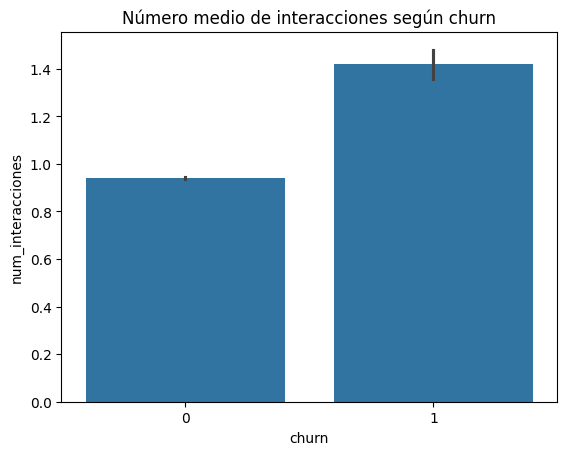

In [326]:
sns.barplot(data=df, x="churn", y="num_interacciones")
plt.title("Número medio de interacciones según churn")
plt.show()

In [327]:
# =========================
# 13. SATISFACCIÓN Y CHURN
# =========================

df.groupby("churn")["satisfaccion_media"].mean()

churn
0    1.914007
1    2.365945
Name: satisfaccion_media, dtype: float64

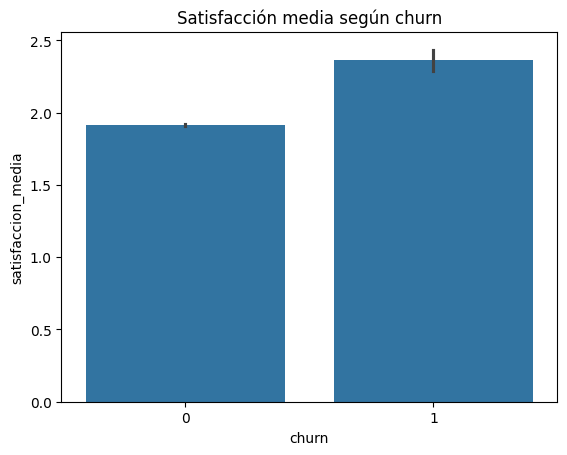

In [328]:
sns.barplot(data=df, x="churn", y="satisfaccion_media")
plt.title("Satisfacción media según churn")
plt.show()

In [329]:
# =========================
# 15. ANÁLISIS POR MOTIVO
# =========================

motivo_churn = soporte.merge(churn, left_on=["cliente_id", "mes"], right_on=["cliente_id", "fecha"], how="left")

motivo_churn.groupby("motivo")["churn"].mean().sort_values(ascending=False)

motivo
Impago / pago            0.013220
Baja / portabilidad      0.009657
Facturación              0.009551
Desconocido              0.008995
Cobertura / velocidad    0.008595
Calidad de señal         0.008416
Consulta general         0.007898
Cambio de plan           0.006758
Name: churn, dtype: float64

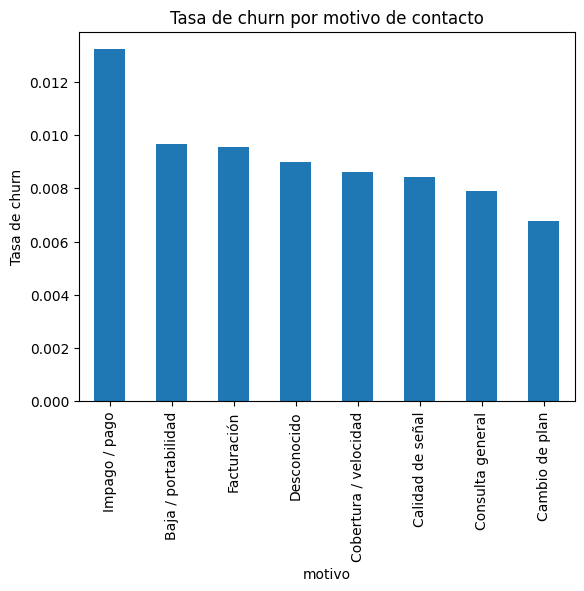

In [330]:
motivo_churn.groupby("motivo")["churn"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Tasa de churn por motivo de contacto")
plt.ylabel("Tasa de churn")
plt.show()

In [331]:
# =========================
# 16. ANÁLISIS POR CANAL
# =========================

motivo_churn.groupby("canal")["churn"].mean().sort_values(ascending=False)

canal
email             0.009710
telefono          0.009626
tienda            0.009324
app_chat          0.009024
fax               0.008114
carrier-pigeon    0.005806
paloma            0.005232
Name: churn, dtype: float64

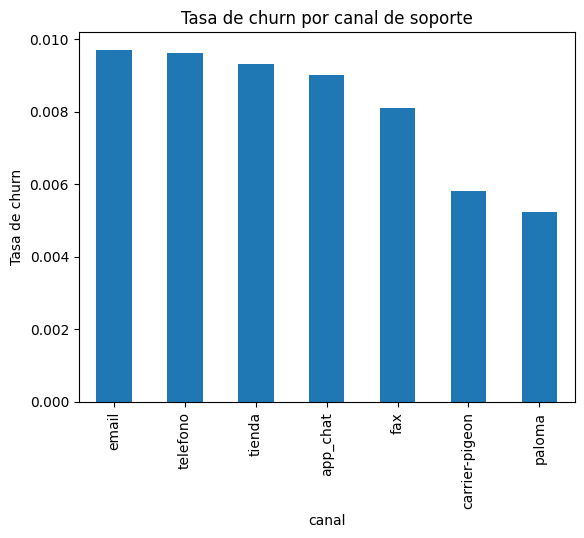

In [332]:
motivo_churn.groupby("canal")["churn"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Tasa de churn por canal de soporte")
plt.ylabel("Tasa de churn")
plt.show()

In [333]:
# =========================
# 17. VARIABLES PARA MODELO
# =========================

variables = [
    "num_interacciones",
    "duracion_media",
    "incidencias_no_resueltas",
    "satisfaccion_media",
    "stress_calidad_medio",
    "incidencias_masivas",
    "impagos",
    "dias_retraso_medio",
    "edad",
    "num_lineas",
    "ingreso_estimado",
    "antiguedad_meses",
    "descuento_activo"
]

X = df[variables]
y = df["churn"]

In [334]:
# =========================
# 18. DIVIDIR TRAIN Y TEST
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [335]:
# =========================
# 19. ÁRBOL DE DECISIÓN
# =========================

modelo_arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

modelo_arbol.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [336]:
# =========================
# 20. EVALUACIÓN
# =========================

y_pred = modelo_arbol.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[47815 16183]
 [  217   183]]
              precision    recall  f1-score   support

           0       1.00      0.75      0.85     63998
           1       0.01      0.46      0.02       400

    accuracy                           0.75     64398
   macro avg       0.50      0.60      0.44     64398
weighted avg       0.99      0.75      0.85     64398



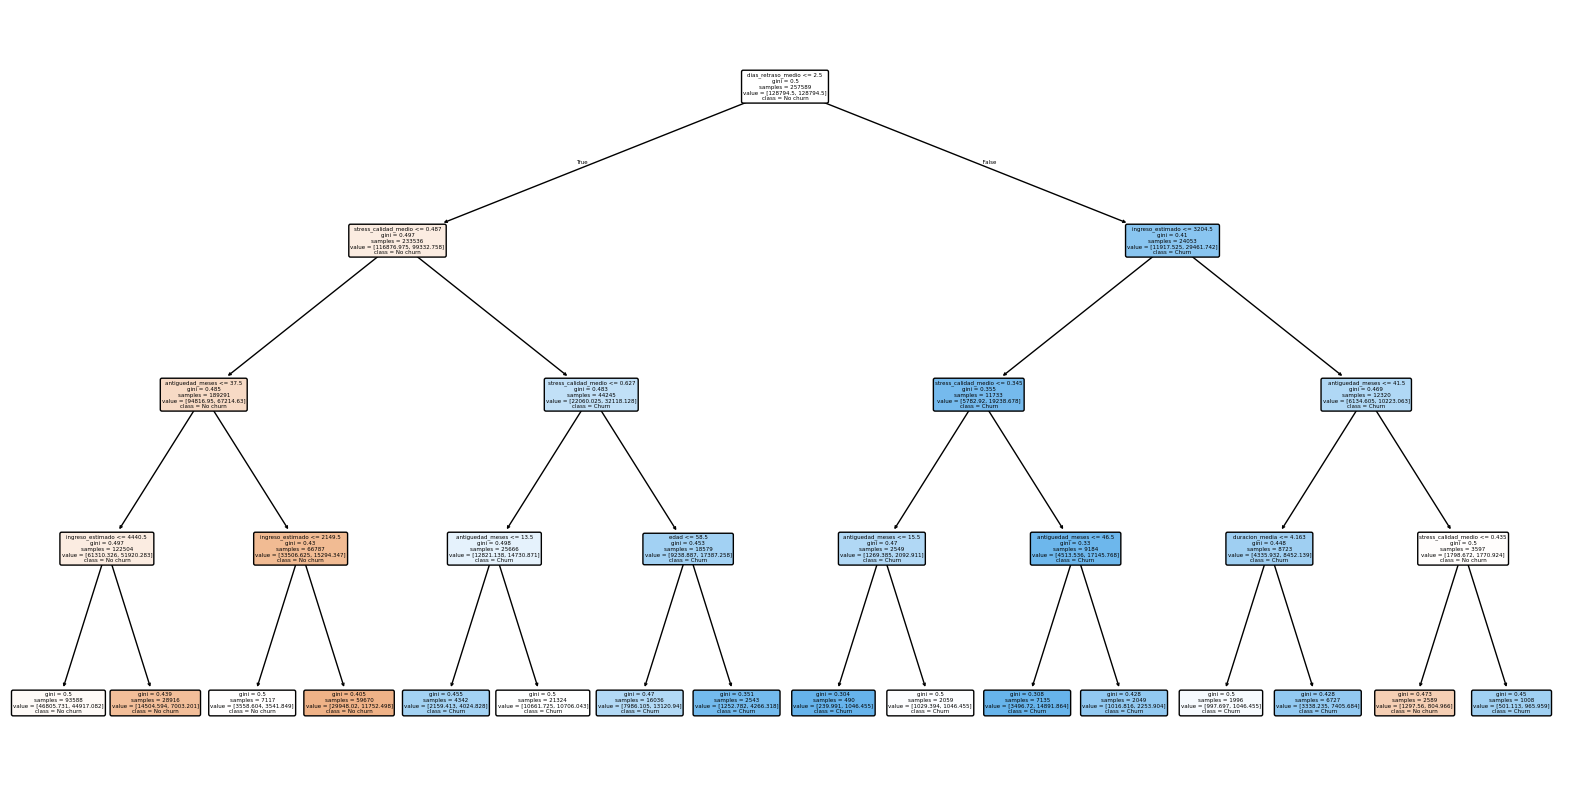

In [337]:
# =========================
# 21. VISUALIZAR ÁRBOL
# =========================

plt.figure(figsize=(20, 10))

plot_tree(
    modelo_arbol,
    feature_names=variables,
    class_names=["No churn", "Churn"],
    filled=True,
    rounded=True
)

plt.show()

In [338]:
# =========================
# 22. IMPORTANCIA DE VARIABLES
# =========================

importancia = pd.DataFrame({
    "variable": variables,
    "importancia": modelo_arbol.feature_importances_
}).sort_values("importancia", ascending=False)

importancia

,variable,importancia
7,dias_retraso_medio,0.370943
4,stress_calidad_medio,0.272074
11,antiguedad_meses,0.170480
10,ingreso_estimado,0.160674
8,edad,0.016784
1,duracion_media,0.009046
0,num_interacciones,0.000000
2,incidencias_no_resueltas,0.000000
3,satisfaccion_media,0.000000
5,incidencias_masivas,0.000000


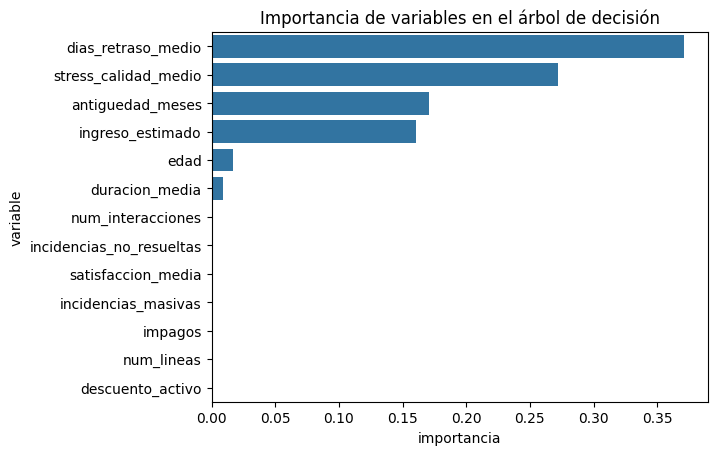

In [339]:
sns.barplot(data=importancia, x="importancia", y="variable")
plt.title("Importancia de variables en el árbol de decisión")
plt.show()

Hipótesis
Los clientes con un mayor número de interacciones con soporte tienen mayor probabilidad de hacer churn.
Las incidencias no resueltas aumentan la probabilidad de abandono del cliente.
Los clientes con niveles bajos de satisfacción después del soporte presentan mayores tasas de churn.
Algunos motivos de contacto con soporte están más relacionados con el churn que otros.
El canal de atención utilizado puede influir en la experiencia del cliente y en su probabilidad de abandono.
Las variables relacionadas con soporte, incidencias y satisfacción pueden ayudar a predecir el churn mediante modelos de machine learning.

En conclusión, el análisis exploratorio mostró que las interacciones con soporte técnico tienen una relación importante con el churn de los clientes. Se observó que los clientes que contactan más veces con soporte, presentan incidencias no resueltas o muestran bajos niveles de satisfacción después de la atención tienen una mayor probabilidad de abandonar el servicio. Además, algunos motivos de contacto, especialmente los relacionados con problemas técnicos, aparecen asociados a mayores tasas de churn. El estudio también permitió comprobar que las variables de soporte y satisfacción aportan información útil para modelos predictivos, ayudando a identificar clientes con riesgo de abandono y facilitando la toma de decisiones para mejorar la experiencia del cliente y reducir la fuga de usuarios.

In [340]:
import pandas as pd
import numpy as np

# 1. Cargar desde RAW
soporte_limpio = pd.read_csv("data/raw/interacciones_soporte.csv")

# 2. Limpiar fecha_evento
soporte_limpio["fecha_evento"] = pd.to_datetime(
    soporte_limpio["fecha_evento"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# 3. Arreglar motivo
soporte_limpio["motivo"] = soporte_limpio["motivo"].fillna("Sin especificar")

# 4. Arreglar satisfaccion_post
soporte_limpio["satisfaccion_post"] = pd.to_numeric(
    soporte_limpio["satisfaccion_post"],
    errors="coerce"
)

soporte_limpio["satisfaccion_post"] = soporte_limpio["satisfaccion_post"].fillna(
    soporte_limpio["satisfaccion_post"].median()
)

# 5. Check final
print("NULLS POR COLUMNA:")
print(soporte_limpio.isnull().sum())

print("\nTOTAL NULLS:")
print(soporte_limpio.isnull().sum().sum())

# 6. Guardar limpio
soporte_limpio.to_csv("data/processed/soporte_limpio.csv", index=False)

NULLS POR COLUMNA:
interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
dtype: int64

TOTAL NULLS:
0


In [341]:
# =====================================================
# LIMPIEZA FINAL - SOPORTE_LIMPIO
# =====================================================

# -------------------------------
# 1. Eliminar duplicados
# -------------------------------

soporte_limpio = soporte_limpio.drop_duplicates()

# -------------------------------
# 2. Eliminar duraciones negativas
# -------------------------------

soporte_limpio = soporte_limpio[
    soporte_limpio["duracion_min"] >= 0
]

# =====================================================
# VERIFICACIÓN FINAL
# =====================================================

print("DUPLICADOS:")
print(soporte_limpio.duplicated().sum())

print("\nNEGATIVOS EN duracion_min:")
print((soporte_limpio["duracion_min"] < 0).sum())

print("\nSHAPE FINAL:")
print(soporte_limpio.shape)

DUPLICADOS:
0

NEGATIVOS EN duracion_min:
0

SHAPE FINAL:
(299371, 13)


In [342]:
# 6. Guardar limpio
soporte_limpio.to_csv("data/processed/soporte_limpio.csv", index=False)

In [343]:
# =====================================================
# DIAGNÓSTICO COMPLETO - SOPORTE_LIMPIO
# =====================================================

import numpy as np

print("="*70)
print("DIAGNÓSTICO COMPLETO - SOPORTE_LIMPIO")
print("="*70)

# ---------------------------------------------------
# SHAPE
# ---------------------------------------------------

print("\n1. SHAPE:")
print(soporte_limpio.shape)

# ---------------------------------------------------
# NULOS
# ---------------------------------------------------

print("\n2. TOTAL NULLS:")
print(soporte_limpio.isnull().sum().sum())

print("\n3. NULLS PER COLUMN:")
print(soporte_limpio.isnull().sum())

# ---------------------------------------------------
# DUPLICADOS
# ---------------------------------------------------

duplicados = soporte_limpio.duplicated().sum()

print("\n4. DUPLICADOS:")
print(duplicados)

# ---------------------------------------------------
# TIPOS DE DATOS
# ---------------------------------------------------

print("\n5. DATA TYPES:")
print(soporte_limpio.dtypes)

# ---------------------------------------------------
# FECHAS
# ---------------------------------------------------

print("\n6. FECHAS:")

if "fecha_evento" in soporte_limpio.columns:
    print("Min:", soporte_limpio["fecha_evento"].min())
    print("Max:", soporte_limpio["fecha_evento"].max())

# ---------------------------------------------------
# VALORES NEGATIVOS
# ---------------------------------------------------

print("\n7. VALORES NEGATIVOS:")

numeric_cols = soporte_limpio.select_dtypes(include=np.number).columns

negativos = {}

for col in numeric_cols:
    cantidad = (soporte_limpio[col] < 0).sum()

    if cantidad > 0:
        negativos[col] = cantidad

if len(negativos) == 0:
    print("✅ No hay valores negativos")
else:
    print("❌ Hay valores negativos:")
    print(negativos)

# ---------------------------------------------------
# RESULTADO FINAL
# ---------------------------------------------------

print("\n" + "="*70)

if (
    soporte_limpio.isnull().sum().sum() == 0
    and duplicados == 0
    and len(negativos) == 0
):
    print("✅ DATASET COMPLETAMENTE LIMPIO")
else:
    print("❌ DATASET STILL HAS PROBLEMS")

print("="*70)

DIAGNÓSTICO COMPLETO - SOPORTE_LIMPIO

1. SHAPE:
(299371, 13)

2. TOTAL NULLS:
0

3. NULLS PER COLUMN:
interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
dtype: int64

4. DUPLICADOS:
0

5. DATA TYPES:
interaccion_id                      str
cliente_id                          str
fecha_evento             datetime64[us]
mes                                 str
canal                               str
motivo                              str
duracion_min                    float64
resuelto                          int64
satisfaccion_post               float64
stress_calidad_lag              float64
incidencia_masiva_lag             int64
impago_mes                        int64
dias_retraso_mes   